# Ensemble Analysis

This notebook reads in and formats outputs from ensemble simulations so that you can evaluate and plot

### Import packages

In [309]:
#import packages
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from itertools import product
from pathlib import Path


In [310]:
# Directories
# Directories and file naming (new folder-based layout)
project_root = Path(r"C:\\Users\\jessi\\VScode\\Homework_3")
ensembles_root = project_root / 'Ensembles'
root_name = 'static_ensemble_'
folder_prefix = 'ens_static_ensemble_'


# Build the full static ensemble list (3 levels across 7 parameters)
ensembles = list(product((1, 2, 3), repeat=7))
ens_lst = [''.join(str(n) for n in ens) for ens in ensembles]
print(f"Total Ensembles: {len(ensembles)}")


# Read parameter choices from Excel file for DataFrame
param_choice_df = pd.read_excel(r"C:\Users\jessi\VScode\Homework_3\HW3_ParameterTable.xlsx", sheet_name="Sheet1")

# Ensemble Parameters DataFrame
parameter = ["K1 & K3", "Kz ratio lowK", "sy", "R mountains", "ET valley", "ET ratio riparian", "K ratio Streambed"]
cols = [f"{name}" for name in parameter]
ens_params_df = pd.DataFrame(ensembles, columns=cols, index=ens_lst)
ens_params_df.index.name = "Ensembles"



Total Ensembles: 2187


# Setup static variables

In [311]:
nrow = 50       # number of rows
ncol = 50       # number of columns
nlay = 3        # number of layers
dx = 1000       # grid spacing in x (m)
dy = 1000       # grid spacing in y (m)
Lx = ncol * dx
Ly = nrow * dy

# Town well location used for ranking (layer, row, col)
well_loc = (0, 21, 38)


## Read in outputs across all ensemble members and store as arrays 

In [312]:
# setup arrays to store the values (all ensemble members)
head_array =        np.zeros((len(ensembles), nlay, ncol, nrow), dtype=np.float32)
frf_array =         np.zeros((len(ensembles), nlay, ncol, nrow), dtype=np.float32)
fff_array =         np.zeros((len(ensembles), nlay, ncol, nrow), dtype=np.float32)
recharge_array =    np.zeros((len(ensembles), 1, ncol, nrow), dtype=np.float32)
et_array =          np.zeros((len(ensembles), 1, ncol, nrow), dtype=np.float32)
stor_array =        np.zeros((len(ensembles), 1, ncol, nrow), dtype=np.float32)
leakage_array =     np.zeros((len(ensembles), 49), dtype=np.float32)  # 2D by design

# Loop through the ensembles and read the data from each run folder
for i, code in enumerate(ens_lst):
    run_dir = ensembles_root / f'{folder_prefix}{code}'
    head_path = run_dir / f'{root_name}{code}.hds'
    cbc_path = run_dir / f'{root_name}{code}.cbc'

    # Fallbacks if names differ slightly
    if not head_path.exists():
        hds_candidates = sorted(run_dir.glob('*.hds')) if run_dir.exists() else []
        if len(hds_candidates) == 0:
            continue
        head_path = hds_candidates[0]

    if not cbc_path.exists():
        cbc_candidates = sorted(run_dir.glob('*.cbc')) if run_dir.exists() else []
        if len(cbc_candidates) == 0:
            continue
        cbc_path = cbc_candidates[0]

    try:
        # Read heads and cell budget files
        headobj = flopy.utils.binaryfile.HeadFile(str(head_path))
        budgobj = flopy.utils.binaryfile.CellBudgetFile(str(cbc_path))

        # Use final output time for robustness
        htotim = headobj.get_times()[-1]
        btotim = budgobj.get_times()[-1]

        head_array[i, :, :, :] = np.asarray(headobj.get_data(totim=htotim), dtype=np.float32)

        tempfrf = np.asarray(np.squeeze(budgobj.get_data(text='FLOW RIGHT FACE', totim=btotim)), dtype=np.float32)
        frf_array[i, :, :, :] = tempfrf

        tempfff = np.asarray(np.squeeze(budgobj.get_data(text='FLOW FRONT FACE', totim=btotim)), dtype=np.float32)
        fff_array[i, :, :, :] = tempfff

        temprch = np.squeeze(budgobj.get_data(text='RECHARGE', totim=btotim))
        recharge_array[i, :, :, :] = np.asarray(temprch[1], dtype=np.float32)

        tempet = np.squeeze(budgobj.get_data(text='ET', totim=btotim))
        et_array[i, :, :, :] = np.asarray(tempet[1], dtype=np.float32)

        try:
            tempstor = np.squeeze(budgobj.get_data(text='STORAGE', totim=btotim))
            stor_array[i, :, :, :] = np.asarray(tempstor[1], dtype=np.float32)
        except Exception:
            # Many static/steady-state runs won't have storage terms
            pass

        templeak = budgobj.get_data(text='RIVER LEAKAGE', totim=btotim)
        leakage_array[i, :] = np.asarray(templeak[0].q, dtype=np.float32)
    except Exception:
        # Skip incomplete/corrupt runs without stopping the notebook
        continue


## Build full ranked dataframe (all valid runs)

In [313]:
# 1) Compute summary values from FULL arrays (all ensemble slots)
head_at_well_all = head_array[:, well_loc[0], well_loc[1], well_loc[2]].astype(np.float32)

# Example summary values (full set)
et_single_loc_all = et_array[:, 0, 22, 15].astype(np.float32)
et_sum_all = et_array[:, 0, :, :].sum(axis=(1, 2), dtype=np.float32).astype(np.float32)

# Recharge summary (total over domain)
recharge_all = recharge_array[:, 0, :, :].sum(axis=(1, 2), dtype=np.float32).astype(np.float32)

# Storage summary (total over domain)   <-- optional
storage_all = stor_array[:, 0, :, :].sum(axis=(1, 2), dtype=np.float32).astype(np.float32)

# River leakage summaries
leak_single_loc_all = leakage_array[:, 25].astype(np.float32)
leak_total_all = leakage_array.sum(axis=1, dtype=np.float32).astype(np.float32)



# 2) Identify valid runs (loaded outputs only)
valid_mask = ~np.isnan(head_at_well_all)
valid_mask &= np.any(head_array != 0.0, axis=(1, 2, 3))  # skips runs that never loaded
valid_idx = np.where(valid_mask)[0]

if len(valid_idx) == 0:
    raise RuntimeError("No valid ensemble outputs were loaded from the Ensembles directory.")

# Rank by head at town well: highest head first (least drawdown-like effect)
sort_order_within_valid = np.argsort(head_at_well_all[valid_idx])[::-1]
ranked_idx = valid_idx[sort_order_within_valid]



# 3) FULL ranked dataframe (for parameter analysis)
ens_codes_full = [ens_lst[i] for i in ranked_idx]
ensemble_names_full = [f"Ensemble {i+1}" for i in range(len(ranked_idx))]

df_full_ranked = pd.DataFrame({
    "Rank Head High to Low": np.arange(1, len(ranked_idx) + 1, dtype=np.int32),
    "Ensemble": ensemble_names_full,
    "Code": ens_codes_full,
    "Head Town Well (m)": head_at_well_all[ranked_idx].astype(np.float32),  # this is the main ranking metric (m)
    "Recharge": recharge_all[ranked_idx].astype(np.float32),                # model volume/time
    # "ET Single Loc": et_single_loc_all[ranked_idx].astype(np.float32),    # model volume/time
    "ET Total": et_sum_all[ranked_idx].astype(np.float32),                  # model volume/time
    "Storage": storage_all[ranked_idx].astype(np.float32),                # model volume/time
    # "Leakage Single Loc": leak_single_loc_all[ranked_idx].astype(np.float32),
    "Leakage Total": leak_total_all[ranked_idx].astype(np.float32),
})

# Save full dataframe (this is the one to use for parameter-effect analysis)
df_full_ranked.to_csv("ensemble_full_ranked_metrics.csv", index=False)

# Show tables
df_full_ranked.describe().style.format("{:.2f}")

,Rank Head High to Low,Head Town Well (m),Recharge,ET Total,Storage,Leakage Total
count,2187.00,2187.00,2187.00,2187.00,2187.00,2187.00
mean,1094.00,73.94,20160.00,-19576.44,0.00,84853.48
std,631.48,1.92,10649.55,26990.09,0.00,91701.18
min,1.00,65.78,7120.00,-102193.30,0.00,-14741.39
25%,547.50,73.20,7120.00,-33387.85,0.00,12840.68
50%,1094.00,74.40,20160.00,-6738.60,0.00,49038.76
75%,1640.50,75.41,33200.00,-991.10,0.00,115966.45
max,2187.00,77.77,33200.00,-223.72,0.00,357758.31


## Top Heads at town well (Highest heads)

In [314]:
df_full_ranked.head(10).style.format({col: "{:,.2f}" for col in df_full_ranked.select_dtypes(include="number").columns})

,Rank Head High to Low,Ensemble,Code,Head Town Well (m),Recharge,ET Total,Storage,Leakage Total
0,1.00,Ensemble 1,1133111,77.77,"33,200.00",-695.01,0.00,"-12,311.39"
1,2.00,Ensemble 2,1113111,77.77,"33,200.00",-695.01,0.00,"-12,311.39"
2,3.00,Ensemble 3,1123111,77.77,"33,200.00",-695.01,0.00,"-12,311.39"
3,4.00,Ensemble 4,1133121,77.68,"33,200.00","-1,014.95",0.00,"-12,099.26"
4,5.00,Ensemble 5,1123121,77.68,"33,200.00","-1,014.95",0.00,"-12,099.26"
5,6.00,Ensemble 6,1113121,77.68,"33,200.00","-1,014.95",0.00,"-12,099.26"
6,7.00,Ensemble 7,1133131,77.59,"33,200.00","-1,334.24",0.00,"-11,887.35"
7,8.00,Ensemble 8,1113131,77.59,"33,200.00","-1,334.24",0.00,"-11,887.35"
8,9.00,Ensemble 9,1123131,77.59,"33,200.00","-1,334.24",0.00,"-11,887.35"
9,10.00,Ensemble 10,1132111,76.17,"20,160.00",-540.80,0.00,"-3,525.41"


## Bottom Heads at town well (Lowest Heads)

In [315]:
df_full_ranked.tail(10).style.format({col: "{:,.2f}" for col in df_full_ranked.select_dtypes(include="number").columns})

,Rank Head High to Low,Ensemble,Code,Head Town Well (m),Recharge,ET Total,Storage,Leakage Total
2177,"2,178.00",Ensemble 2178,1231321,66.31,"7,120.00","-9,916.22",0.00,"6,000.00"
2178,"2,179.00",Ensemble 2179,1321321,66.28,"7,120.00","-9,917.54",0.00,"6,000.00"
2179,"2,180.00",Ensemble 2180,1311321,66.28,"7,120.00","-9,917.54",0.00,"6,000.00"
2180,"2,181.00",Ensemble 2181,1331321,66.28,"7,120.00","-9,917.54",0.00,"6,000.00"
2181,"2,182.00",Ensemble 2182,1211331,65.81,"7,120.00","-11,017.57",0.00,"6,000.00"
2182,"2,183.00",Ensemble 2183,1221331,65.81,"7,120.00","-11,017.57",0.00,"6,000.00"
2183,"2,184.00",Ensemble 2184,1231331,65.81,"7,120.00","-11,017.57",0.00,"6,000.00"
2184,"2,185.00",Ensemble 2185,1321331,65.78,"7,120.00","-11,019.85",0.00,"6,000.00"
2185,"2,186.00",Ensemble 2186,1331331,65.78,"7,120.00","-11,019.85",0.00,"6,000.00"
2186,"2,187.00",Ensemble 2187,1311331,65.78,"7,120.00","-11,019.85",0.00,"6,000.00"


## N evenly spaced ranked picks over the full data run for plotting

In [316]:
n_pick = 250  # number of picks for inspection (evenly spaced across the ranked list)
pick_positions = np.linspace(0, len(ranked_idx) - 1, min(n_pick, len(ranked_idx)), dtype=int)
pick_positions = list(dict.fromkeys(pick_positions.tolist()))  # remove duplicates if rounding repeats
sel_idx = ranked_idx[pick_positions]

# 20-pick dataframe (same columns, already ranked high -> low)
df_ranked20 = df_full_ranked.iloc[pick_positions].copy().reset_index(drop=True)

# # Re-label rank for the 20-picked subset (optional)
df_ranked20["Rank Head High to Low"] = np.arange(1, len(df_ranked20) + 1, dtype=np.int32)

df_ranked20.to_csv("ensemble_ranked20_metrics.csv", index=False)

# Reset labels for downstream cells so they match the trimmed arrays
ens_lst = [ens_lst[i] for i in sel_idx]
ensembles = [ensembles[i] for i in sel_idx]
ensemble_names = df_ranked20["Ensemble"].tolist()

# Recompute trimmed head vector for convenience
head_at_well = head_array[:, well_loc[0], well_loc[1], well_loc[2]].astype(np.float32)

In [349]:
def plot_ranked_metric_bar(
    df,
    y_col,
    ensemble_col="Ensemble",
    color_col="Head Town Well (m)",
    title=None,
    y_label=None,
    x_label="Ensemble (ranked)",
    colorbar_label="Head at Town Well (m)",
):

    plot_df = df.copy()
    y = -plot_df[y_col] if "ET" in title else plot_df[y_col]
    x = np.arange(len(plot_df))
    y = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)
    c = pd.to_numeric(plot_df[color_col], errors="coerce").to_numpy(dtype=float)
    labels = plot_df[ensemble_col].astype(str).tolist()

    fig, ax = plt.subplots(figsize=(20, 8))
    # fig.subplots_adjust(right=0.86)

    norm = mpl.colors.Normalize(vmin=np.nanmin(c), vmax=np.nanmax(c))
    cmap = mpl.colormaps["viridis"]
    bar_colors = cmap(norm(c))

    ax.bar(x, y, color=bar_colors, edgecolor="black", linewidth=0.50, width=0.75)

    ax.axhline(0, color="black", linewidth=1.0, alpha=0.8)
    y_mean = np.nanmean(y)
    ax.axhline(y_mean, color="black", linestyle="--", linewidth=1.5, label=f"Mean = {y_mean:,.0f}")
    y_med = np.nanmedian(y)
    ax.axhline(y_med, color="red", linestyle=":", linewidth=1.5, label=f"Median = {y_med:,.0f}")
    y_max = np.nanmax(y)
    ax.axhline(y_max, color="grey", linestyle="-.", linewidth=1.5, label=f"Maximum = {y_max:,.0f}")
    y_min = np.nanmin(y)
    ax.axhline(y_min, color="grey", linestyle="-", linewidth=1.5, label=f"Minimum = {y_min:,.0f}")

    ax.set_title(title if title else y_col)
    ax.set_ylabel(y_label if y_label else y_col)
    ax.set_xlabel(x_label)
    ax.set_ylim(y.min() if "River" or "ET" not in title else 65, y_max*1.01)
    # ax.set_ylim(y_lim_low, y_lim_high)
    ax.grid(axis="y", alpha=0.25)

    # Tick thinning for readability
    if len(x) <= 40:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=90)
    else:
        step = int(np.ceil(len(x) / 35))
        tick_idx = x[::step]
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([labels[i] for i in tick_idx], rotation=90)

    # Colorbar
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.05)
    cbar.set_label(colorbar_label)

    ax.legend(loc="best", fontsize=10, framealpha=1.0)
    plt.show()

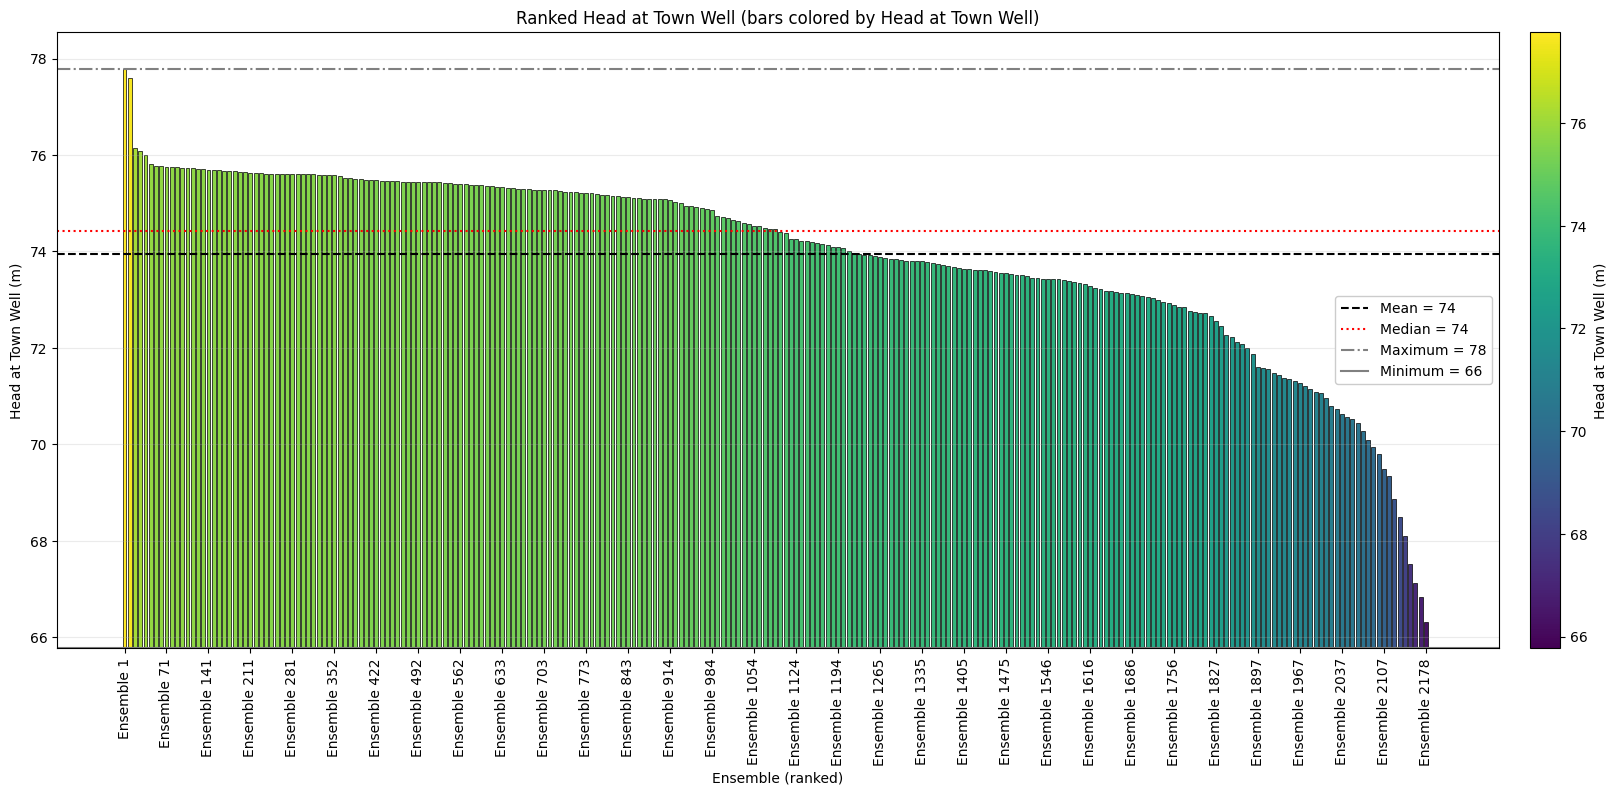

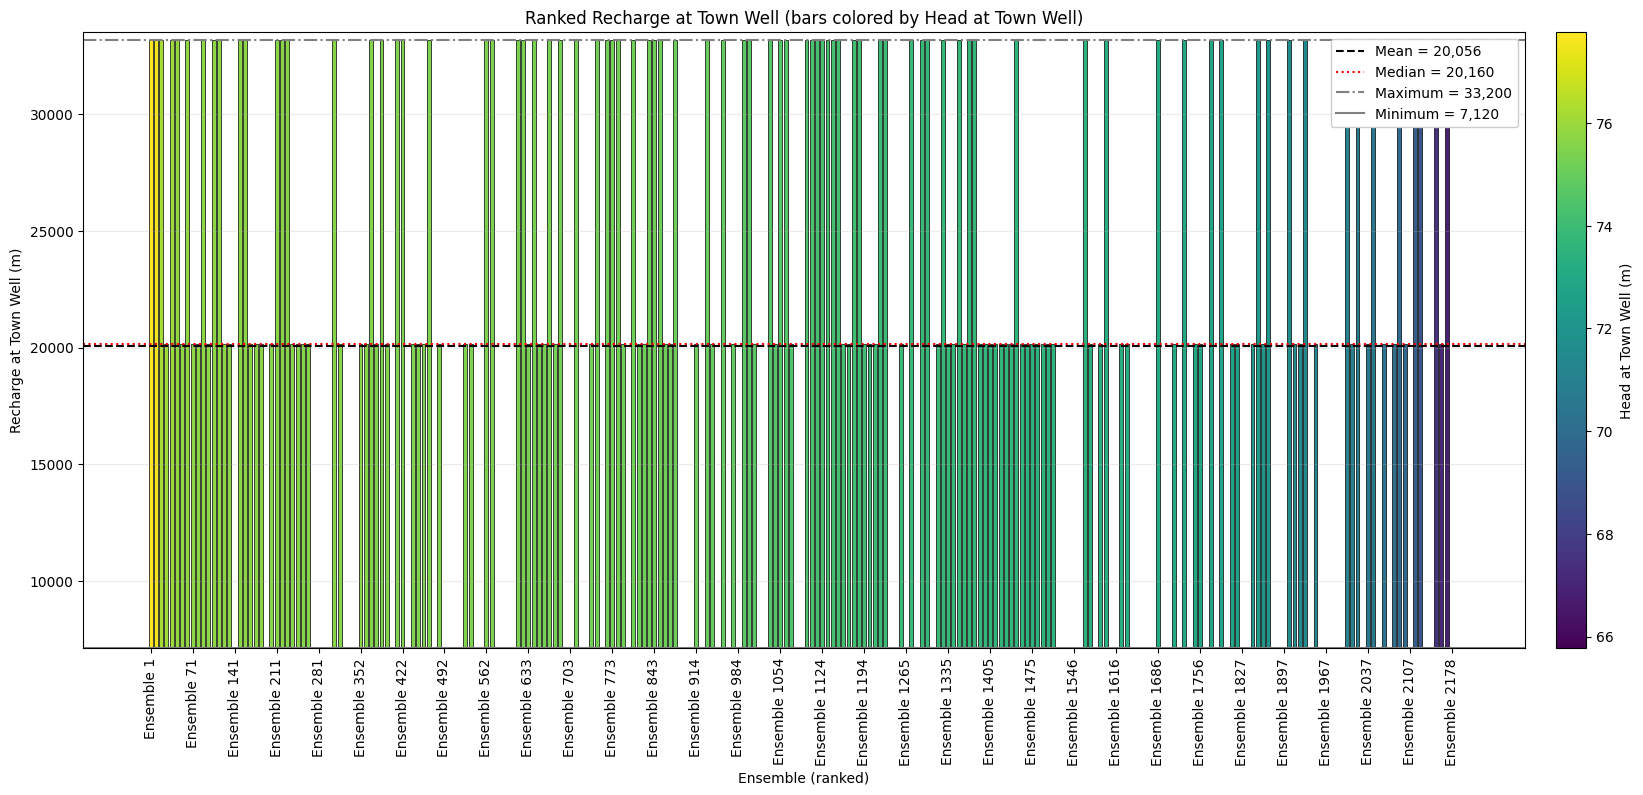

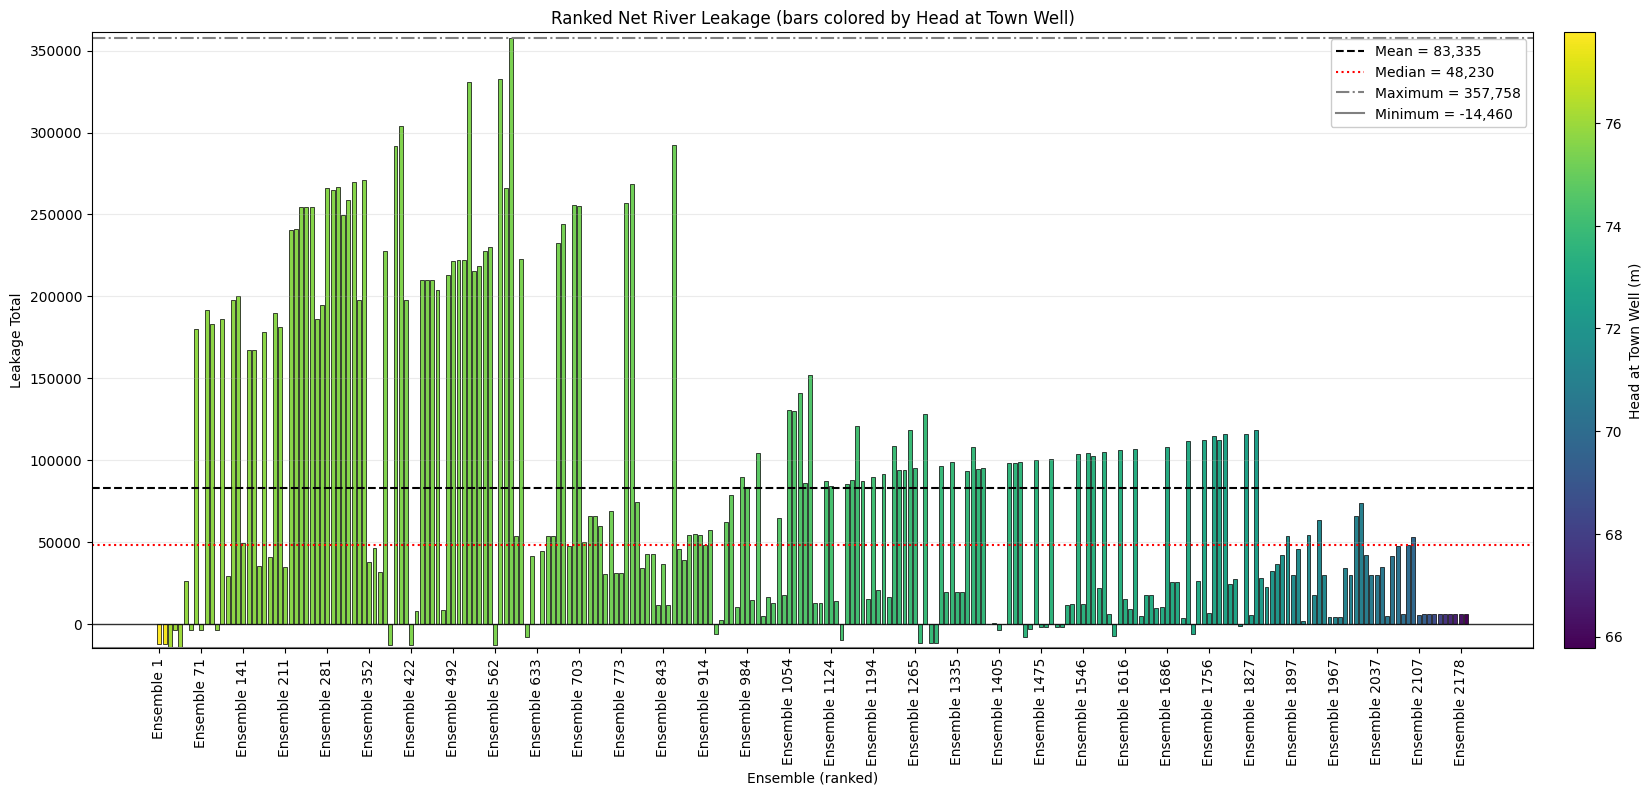

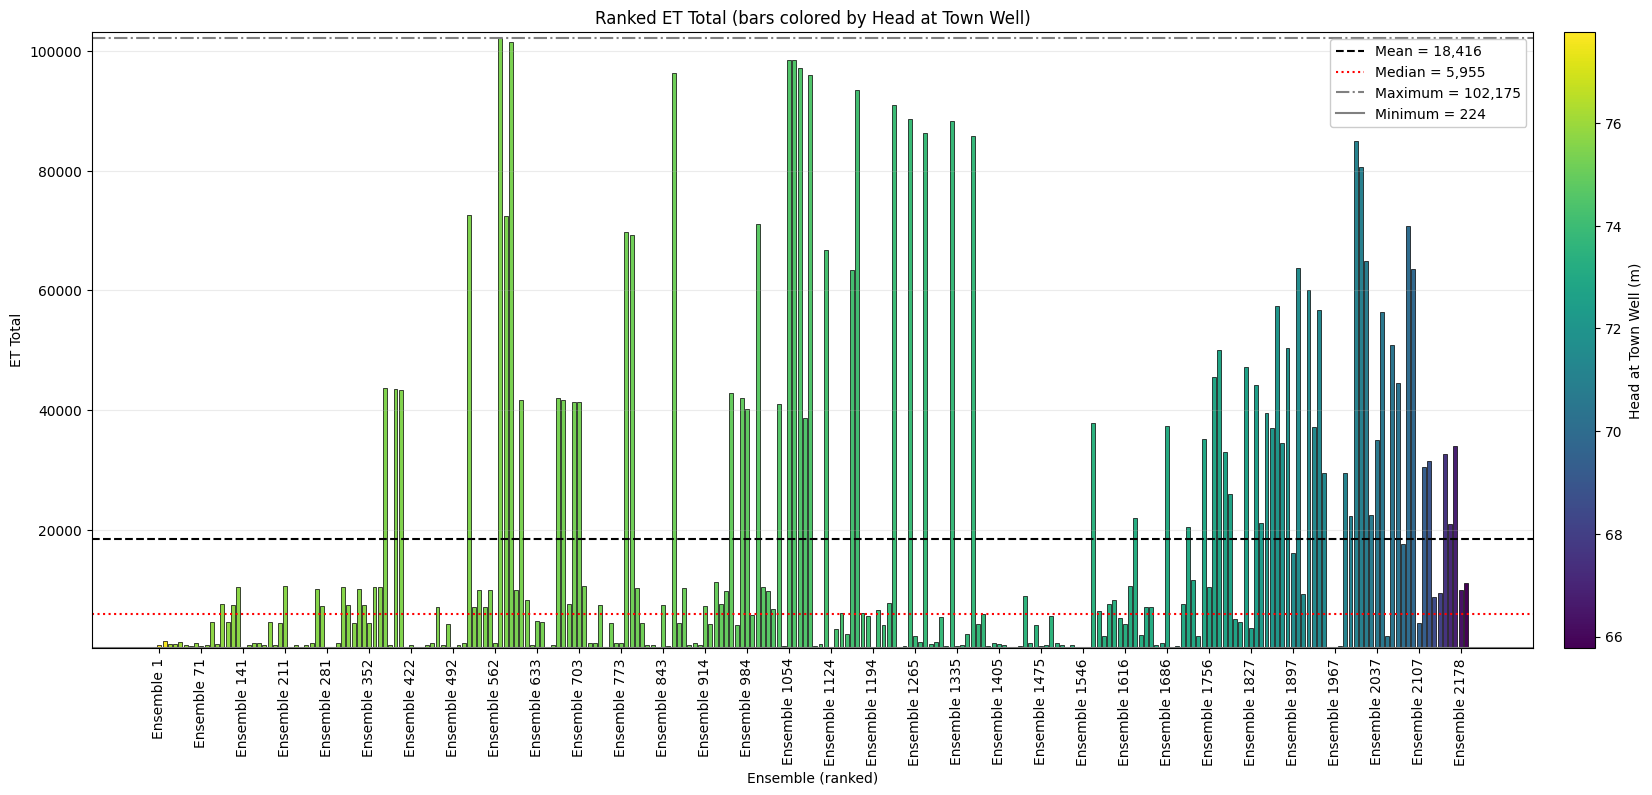

In [350]:
# Head
plot_ranked_metric_bar(
    df_ranked20,
    y_col="Head Town Well (m)",
    title="Ranked Head at Town Well (bars colored by Head at Town Well)",
    y_label="Head at Town Well (m)",
)

# Head
plot_ranked_metric_bar(
    df_ranked20,
    y_col="Recharge",
    title="Ranked Recharge at Town Well (bars colored by Head at Town Well)",
    y_label="Recharge at Town Well (m)",
)

# Leakage
plot_ranked_metric_bar(
    df_ranked20,
    y_col="Leakage Total",
    title="Ranked Net River Leakage (bars colored by Head at Town Well)",
    y_label="Leakage Total"
)

# ET (raw, negative)
plot_ranked_metric_bar(
    df_ranked20,
    y_col="ET Total",
    title="Ranked ET Total (bars colored by Head at Town Well)",
    y_label="ET Total"
)

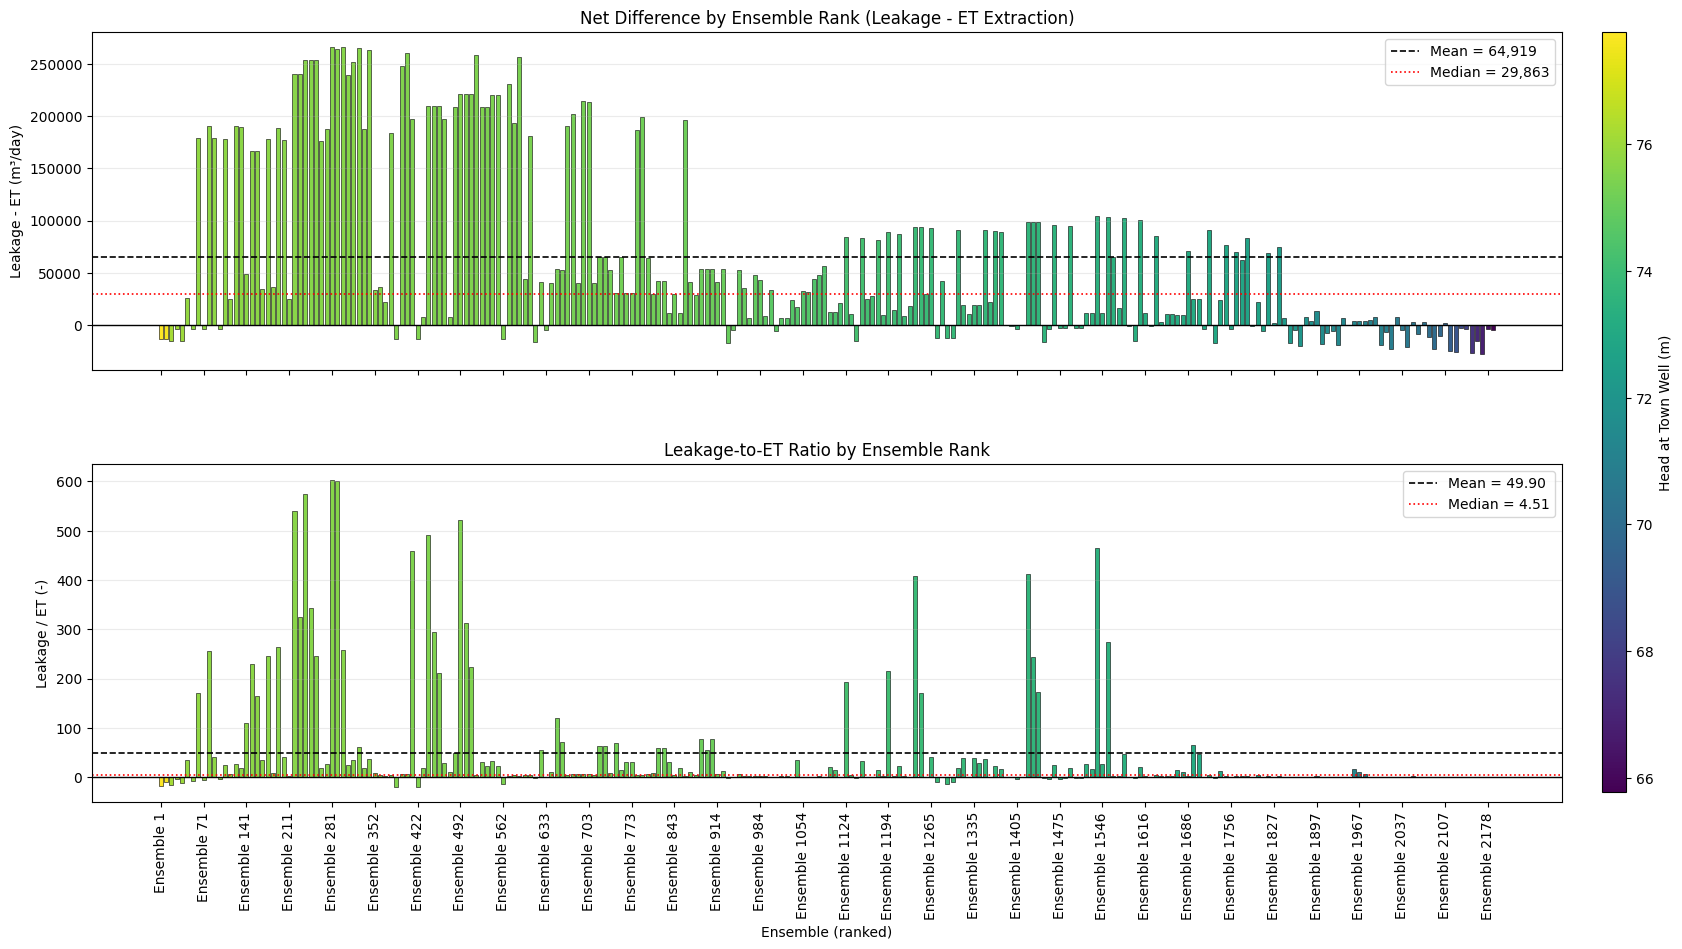

In [319]:
df_net = df_ranked20.copy()

# Build both metrics (same row order as df_ranked20)
df_net["net_diff"] = df_net["Leakage Total"] + df_net["ET Total"]  # + because ET is negative in raw outputs, so this is effectively leakage - extraction
df_net["net_ratio"] = df_net["Leakage Total"] / -df_net["ET Total"].replace(0, np.nan)

# Shared x-axis from the existing ranked dataframe
x = np.arange(len(df_net))
labels = df_net["Ensemble"].astype(str).tolist()

# Shared head color scale (same colors mean same head on both panels)
head_all = df_net["Head Town Well (m)"].to_numpy(dtype=float)
norm = mpl.colors.Normalize(vmin=np.nanmin(head_all), vmax=np.nanmax(head_all))
cmap = plt.cm.viridis
bar_colors = cmap(norm(head_all))

# Figure + shared x-axis
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True, gridspec_kw={"hspace": 0.28})
fig.subplots_adjust(right=0.86)  # leave room for manual colorbar

# -----------------------
# Panel 1: Difference
# -----------------------
ax = axes[0]
y1 = df_net["net_diff"].to_numpy(dtype=float)

ax.bar(x, y1, color=bar_colors, edgecolor="black", linewidth=0.40, width=0.75)

mean1 = np.nanmean(y1)
median1 = np.nanmedian(y1)

ax.axhline(0, color="black", linewidth=1.0)
ax.axhline(mean1, color="black", linestyle="--", linewidth=1.2, label=f"Mean = {mean1:,.0f}")
ax.axhline(median1, color="red", linestyle=":", linewidth=1.2, label=f"Median = {median1:,.0f}")

ax.set_title("Net Difference by Ensemble Rank (Leakage - ET Extraction)")
ax.set_ylabel("Leakage - ET (m³/day)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="best")

# -----------------------
# Panel 2: Ratio
# -----------------------
ax = axes[1]
y2 = df_net["net_ratio"].to_numpy(dtype=float)

ax.bar(x, y2, color=bar_colors, edgecolor="black", linewidth=0.40, width=0.75)

mean2 = np.nanmean(y2)
median2 = np.nanmedian(y2)

ax.axhline(0, color="black", linewidth=1.0)
# ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8, label="Ratio = 1.0")
ax.axhline(mean2, color="black", linestyle="--", linewidth=1.2, label=f"Mean = {mean2:,.2f}")
ax.axhline(median2, color="red", linestyle=":", linewidth=1.2, label=f"Median = {median2:,.2f}")

ax.set_title("Leakage-to-ET Ratio by Ensemble Rank")
ax.set_xlabel("Ensemble (ranked)")
ax.set_ylabel("Leakage / ET (-)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="best")

# Same x tick thinning logic as your other plots
if len(x) <= 40:
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=90)
else:
    step = int(np.ceil(len(x) / 35))
    tick_idx = x[::step]
    axes[1].set_xticks(tick_idx)
    axes[1].set_xticklabels([labels[i] for i in tick_idx], rotation=90)

# Manual colorbar axis (this is what makes it truly skinny)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# [left, bottom, width, height] in figure coordinates
cax = fig.add_axes([0.88, 0.12, 0.012, 0.76])  # width=0.012 -> skinny
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Head at Town Well (m)")

plt.show()

## 1) Build a clean full-analysis dataframe from df_full_ranked

In [320]:
# Use the FULL dataframe (not df_ranked20)
src = df_full_ranked.copy()

# Normalize names so code below is easier to write
df_effect = src.rename(columns={
    "Ensemble": "ensemble_name",
    "Code": "ens_code",
    "Head Town Well (m)": "head_town_m",
    "Recharge": "recharge_total",
    "ET Single Loc": "et_single_loc",
    "ET Total": "et_total",
    "Storage": "storage_total",
    "Leakage Single Loc": "leak_single_loc",
    "Leakage Total": "leak_total",
}).copy()

# Clean types
df_effect["ens_code"] = (
    df_effect["ens_code"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)   # keep only digits
    .str.zfill(7)                          # ensure 7 characters
)

for col in ["head_town_m", "recharge_total", "et_single_loc", "et_total", "storage_total", "leak_single_loc", "leak_total"]:
    if col in df_effect.columns:
        df_effect[col] = pd.to_numeric(df_effect[col], errors="coerce").astype(np.float32)

df_effect = df_effect.dropna(subset=["ens_code", "head_town_m"]).reset_index(drop=True)

df_effect.sample(5).style.format({col: "{:.2f}" for col in df_effect.select_dtypes(include="number").columns})

,Rank Head High to Low,ensemble_name,ens_code,head_town_m,recharge_total,et_total,storage_total,leak_total
797,798.00,Ensemble 798,2211233,75.18,7120.00,-10266.20,0.00,74132.01
47,48.00,Ensemble 48,2133133,75.80,33200.00,-1076.28,0.00,26773.53
632,633.00,Ensemble 633,1122213,75.33,20160.00,-4675.34,0.00,320.40
2079,2080.00,Ensemble 2080,1132311,70.08,20160.00,-17552.73,0.00,5981.95
1831,1832.00,Ensemble 1832,1112312,72.50,20160.00,-30910.92,0.00,22501.29


## Split ens_code into factor columns (f1…f7)

In [321]:
# Split 7-digit ensemble code into factor levels (1/2/3)
factor_cols = [f"f{i}" for i in range(1, 8)]

split_df = pd.DataFrame(
    df_effect["ens_code"].apply(lambda s: [int(ch) for ch in s]).tolist(),
    columns=factor_cols
).astype(np.int8)

df_effect = pd.concat([df_effect, split_df], axis=1)

df_effect.sample(5).style.format({col: "{:.2f}" for col in df_effect.select_dtypes(include="number").columns})

,Rank Head High to Low,ensemble_name,ens_code,head_town_m,recharge_total,et_total,storage_total,leak_total,f1,f2,f3,f4,f5,f6,f7
1087,1088.00,Ensemble 1088,2231333,74.46,7120.00,-95947.12,0.00,152030.66,2.00,2.00,3.00,1.00,3.00,3.00,3.00
1169,1170.00,Ensemble 1170,2122333,74.16,20160.00,-93572.16,0.00,121118.95,2.00,1.00,2.00,2.00,3.00,3.00,3.00
989,990.00,Ensemble 990,2331313,74.85,7120.00,-41351.48,0.00,101464.83,2.00,3.00,3.00,1.00,3.00,1.00,3.00
815,816.00,Ensemble 816,2333212,75.16,33200.00,-4456.42,0.00,34317.61,2.00,3.00,3.00,3.00,2.00,1.00,2.00
309,310.00,Ensemble 310,2131122,75.60,7120.00,-719.62,0.00,46181.83,2.00,1.00,3.00,1.00,1.00,2.00,2.00


## Response distributions by parameter level (1, 2, 3)

These boxplots come **after the factor split** because they use the `f1`–`f7` columns directly.

,Parameter Name,Description,Low (1),Medium (2),High (3),factor_col
0,K1 & K3,K in upper and lower layers [m/day],5.000000,25.00000,100.00000,f1
1,Kzratio lowK,Ratio of Kz in the middle low-K layer to basel...,0.000001,0.01000,1.00000,f2
2,sy,Specific Yield [-],0.050000,0.10000,0.30000,f3
3,R mountains,Recharge rate in mountains [m/day],0.000010,0.00003,0.00005,f4
4,ET valley,ET rate in valley [m/day],0.000001,0.00001,0.00010,f5
5,ETration riparian,Ratio of ET in riparian area to ET rate in val...,1.000000,2.00000,3.00000,f6
6,Kratio Streambed,Ratio of K in streambed to baseline K (-),0.010000,0.10000,1.00000,f7


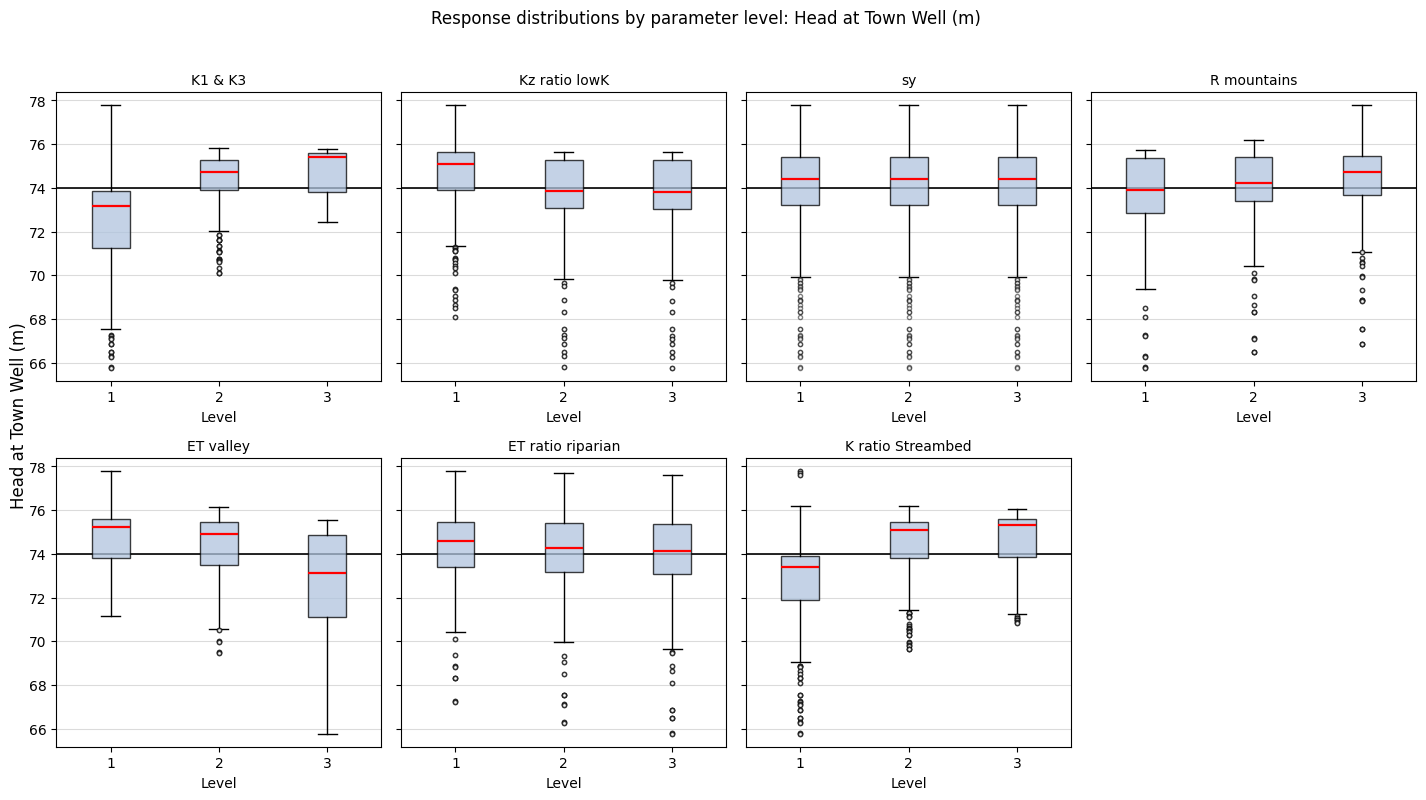

In [322]:
# Boxplots by category/factor level (1, 2, 3) for Head, ET, and Leakage
# Assumes df_effect already exists and has factor columns f1..f7 (created in the previous cell).
pc = param_choice_df.copy()

# If needed, rename columns to match your downstream code
# (Only run the rename lines that apply to your actual column names)
rename_map = {}
if "Parameter" in pc.columns and "Parameter Name" not in pc.columns:
    rename_map["Parameter"] = "Parameter Name"
if "Low" in pc.columns and "Low (1)" not in pc.columns:
    rename_map["Low"] = "Low (1)"
if "Medium" in pc.columns and "Medium (2)" not in pc.columns:
    rename_map["Medium"] = "Medium (2)"
if "Med" in pc.columns and "Medium (2)" not in pc.columns:
    rename_map["Med"] = "Medium (2)"
if "High" in pc.columns and "High (3)" not in pc.columns:
    rename_map["High"] = "High (3)"

if rename_map:
    pc = pc.rename(columns=rename_map)

# Add factor_col if missing (assumes same order as your 7 factors)
if "factor_col" not in pc.columns:
    pc["factor_col"] = [f"f{i}" for i in range(1, len(pc) + 1)]

display(pc)


# Make sure factor columns exist (safe fallback)
factor_cols = [f"f{i}" for i in range(1, 8)]
if not all(fc in df_effect.columns for fc in factor_cols):
    split_df = pd.DataFrame(
        df_effect["ens_code"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(7).apply(lambda s: [int(ch) for ch in s]).tolist(),
        columns=factor_cols
    ).astype(np.int8)
    df_effect = pd.concat([df_effect, split_df], axis=1)

# Parameter labels: prefer real names from ens_params_df, then pc, otherwise generic names
param_label_map = {}

# 1) ens_params_df columns (best source for real names in this notebook)
if "ens_params_df" in globals():
    try:
        if isinstance(ens_params_df, pd.DataFrame) and ens_params_df.shape[1] >= 7:
            for i, col in enumerate(list(ens_params_df.columns)[:7], start=1):
                param_label_map[f"f{i}"] = str(col)
    except Exception:
        pass

# 2) pc (if available) can still override or fill gaps
if "pc" in globals():
    try:
        if isinstance(pc, pd.DataFrame):
            if "factor_col" in pc.columns and "Parameter Name" in pc.columns:
                for _, row in pc.iterrows():
                    fc = str(row["factor_col"])
                    pname = str(row["Parameter Name"])
                    if fc and pname and fc not in param_label_map:
                        param_label_map[fc] = pname
            elif "Parameter" in pc.columns:
                for _, row in pc.iterrows():
                    key = f"f{int(row['Parameter'])}" if str(row["Parameter"]).isdigit() else str(row["Parameter"])
                    param_label_map.setdefault(key, str(row.get("Name", row.get("ParameterName", key))))
    except Exception:
        pass

for i, fc in enumerate(factor_cols, start=1):
    param_label_map.setdefault(fc, f"Parameter {i}")

def plot_boxplots_by_factor(df, response_col, response_label, transform=None):
    tmp = df.copy()
    vals = pd.to_numeric(tmp[response_col], errors="coerce")
    if transform is not None:
        vals = transform(vals)
    tmp["_resp_plot_"] = vals

    fig, axes = plt.subplots(2, 4, figsize=(14.5, 7.8), sharey=True)
    axes = axes.ravel()

    for idx, fc in enumerate(factor_cols):
        ax = axes[idx]
        data_groups = [
            tmp.loc[tmp[fc] == lvl, "_resp_plot_"].dropna().to_numpy(dtype=float)
            for lvl in [1, 2, 3]
        ]

        ax.axhline(74, color="black", linestyle="-", linewidth=1.2)
        
        bp = ax.boxplot(
            data_groups,
            tick_labels=["1", "2", "3"],   # Matplotlib 3.9+
            patch_artist=True,             # required for filled boxes
            widths=0.35
        )

        # --- Styling: filled boxes + red medians ---
        for box in bp["boxes"]:
            box.set_facecolor("lightsteelblue")
            box.set_alpha(0.75)
            box.set_edgecolor("black")
            box.set_linewidth(1.0)

        for med in bp["medians"]:
            med.set_color("red")
            med.set_linewidth(1.6)

        for whisk in bp["whiskers"]:
            whisk.set_color("black")
            whisk.set_linewidth(1.0)

        for cap in bp["caps"]:
            cap.set_color("black")
            cap.set_linewidth(1.0)

        for flier in bp["fliers"]:
            flier.set_marker("o")
            flier.set_markersize(3)
            flier.set_alpha(0.5)
            flier.set_markeredgecolor("black")
            flier.set_markerfacecolor("white")

        ax.set_title(param_label_map.get(fc, fc), fontsize=10)
        ax.set_xlabel("Level")
        ax.grid(True, axis="y", alpha=0.45)

    # hide unused 8th axis
    axes[-1].axis("off")

    # Single y-axis label for the whole figure
    fig.supylabel(response_label)

    fig.suptitle(f"Response distributions by parameter level: {response_label}", y=1.02)
    plt.tight_layout()
    plt.show()

# Head
plot_boxplots_by_factor(df_effect, response_col="head_town_m", response_label="Head at Town Well (m)")

# # ET (plot as positive extraction)
# plot_boxplots_by_factor(df_effect, response_col="et_total", response_label="ET Total (m³/day) [positive extraction]", transform=lambda s: -s)

# # Leakage (raw sign convention; keep as-is)
# plot_boxplots_by_factor(df_effect, response_col="leak_total", response_label="Net River Leakage (m³/day)")

## Main-effects summary for Head Town Well (m) (most/least influential parameters)

In [323]:
def summarize_parameter_effects(df, param_table, response_col):
    """
    Compute one-factor-at-a-time effects on response_col.

    Returns:
        df_param_effects: one row per parameter, sorted by strongest effect
        df_param_levels:  one row per parameter level (Low/Med/High) with stats
    """
    y = pd.to_numeric(df[response_col], errors="coerce").astype(np.float32)
    valid = y.notna()
    y = y[valid]

    overall_mean = float(y.mean())
    ss_total = float(((y - overall_mean) ** 2).sum())

    summary_rows = []
    detail_rows = []

    for _, prow in param_table.iterrows():
        fcol = prow["factor_col"]
        pname = prow["Parameter Name"]

        # Level stats (1,2,3) for this parameter
        g = (
            df.loc[valid]
              .groupby(fcol)[response_col]
              .agg(["count", "mean", "std", "min", "max"])
              .reindex([1, 2, 3])
        )

        counts = pd.to_numeric(g["count"], errors="coerce").fillna(0).astype(np.int32)
        means  = pd.to_numeric(g["mean"],  errors="coerce").astype(np.float32)
        stds   = pd.to_numeric(g["std"],   errors="coerce").astype(np.float32)
        mins   = pd.to_numeric(g["min"],   errors="coerce").astype(np.float32)
        maxs   = pd.to_numeric(g["max"],   errors="coerce").astype(np.float32)

        # Effect metrics
        effect_range = np.float32(means.max() - means.min()) if means.notna().any() else np.float32(np.nan)

        if pd.notna(means.loc[1]) and pd.notna(means.loc[3]):
            high_minus_low = np.float32(means.loc[3] - means.loc[1])
        else:
            high_minus_low = np.float32(np.nan)

        ss_between = 0.0
        for lvl in [1, 2, 3]:
            if counts.loc[lvl] > 0 and pd.notna(means.loc[lvl]):
                ss_between += float(counts.loc[lvl]) * float((means.loc[lvl] - overall_mean) ** 2)

        eta_sq = np.float32(ss_between / ss_total) if ss_total > 0 else np.float32(np.nan)

        summary_rows.append({
            "factor_col": fcol,
            "parameter_name": pname,
            "mean_head_low": means.loc[1] if pd.notna(means.loc[1]) else np.float32(np.nan),
            "mean_head_med": means.loc[2] if pd.notna(means.loc[2]) else np.float32(np.nan),
            "mean_head_high": means.loc[3] if pd.notna(means.loc[3]) else np.float32(np.nan),
            "effect_range_m": effect_range,
            "high_minus_low_m": high_minus_low,
            "eta_sq_oneway": eta_sq,
            "low_value": np.float32(prow["Low (1)"]) if pd.notna(prow["Low (1)"]) else np.float32(np.nan),
            "med_value": np.float32(prow["Medium (2)"]) if pd.notna(prow["Medium (2)"]) else np.float32(np.nan),
            "high_value": np.float32(prow["High (3)"]) if pd.notna(prow["High (3)"]) else np.float32(np.nan),
        })

        # Long-form detail rows
        for lvl in [1, 2, 3]:
            level_val = {1: prow["Low (1)"], 2: prow["Medium (2)"], 3: prow["High (3)"]}[lvl]
            detail_rows.append({
                "parameter_name": pname,
                "factor_col": fcol,
                "level": np.int8(lvl),
                "choice_label": {1: "Low", 2: "Medium", 3: "High"}[lvl],
                "parameter_value": np.float32(level_val) if pd.notna(level_val) else np.float32(np.nan),
                "count": counts.loc[lvl],
                "mean_head_m": means.loc[lvl] if pd.notna(means.loc[lvl]) else np.float32(np.nan),
                "std_head_m": stds.loc[lvl] if pd.notna(stds.loc[lvl]) else np.float32(np.nan),
                "min_head_m": mins.loc[lvl] if pd.notna(mins.loc[lvl]) else np.float32(np.nan),
                "max_head_m": maxs.loc[lvl] if pd.notna(maxs.loc[lvl]) else np.float32(np.nan),
            })

    df_param_effects = pd.DataFrame(summary_rows).sort_values("effect_range_m", ascending=False, ignore_index=True)
    df_param_levels = pd.DataFrame(detail_rows)

    # tidy dtypes
    for c in ["mean_head_low", "mean_head_med", "mean_head_high", "effect_range_m", "high_minus_low_m", "eta_sq_oneway",
              "low_value", "med_value", "high_value"]:
        df_param_effects[c] = pd.to_numeric(df_param_effects[c], errors="coerce").astype(np.float32)

    for c in ["parameter_value", "mean_head_m", "std_head_m", "min_head_m", "max_head_m"]:
        df_param_levels[c] = pd.to_numeric(df_param_levels[c], errors="coerce").astype(np.float32)

    df_param_levels["count"] = pd.to_numeric(df_param_levels["count"], errors="coerce").fillna(0).astype(np.int32)
    df_param_levels["level"] = pd.to_numeric(df_param_levels["level"], errors="coerce").fillna(0).astype(np.int8)

    return df_param_effects, df_param_levels


# Run for town well head
df_param_effects, df_param_levels = summarize_parameter_effects(
    df=df_effect,
    param_table=pc,
    response_col="head_town_m"
)

df_param_effects.style.format({
    "mean_head_low": "{:.2f}",
    "mean_head_med": "{:.2f}",
    "mean_head_high": "{:.2f}",
    "effect_range_m": "{:.2f}",
    "high_minus_low_m": "{:.2f}",
    "eta_sq_oneway": "{:.3f}",
    "low_value": "{:.6g}",
    "med_value": "{:.6g}",
    "high_value": "{:.6g}",
})


,factor_col,parameter_name,mean_head_low,mean_head_med,mean_head_high,effect_range_m,high_minus_low_m,eta_sq_oneway,low_value,med_value,high_value
0,f1,K1 & K3,72.61,74.38,74.83,2.22,2.22,0.248,5,25,100
1,f5,ET valley,74.74,74.37,72.71,2.03,-2.03,0.210,1e-06,1e-05,0.0001
2,f7,Kratio Streambed,72.72,74.42,74.68,1.97,1.97,0.205,0.01,0.1,1
3,f2,Kzratio lowK,74.47,73.68,73.67,0.80,-0.80,0.038,1e-06,0.01,1
4,f4,R mountains,73.62,73.96,74.23,0.61,0.61,0.017,1e-05,3e-05,5e-05
5,f6,ETration riparian,74.16,73.92,73.74,0.41,-0.41,0.008,1,2,3
6,f3,sy,73.94,73.94,73.94,0.00,0.00,0.000,0.05,0.1,0.3


## Rounded display tables (easy to read)

In [324]:
df_param_levels.style.format({
    "parameter_value": "{:.6g}",
    "mean_head_m": "{:.2f}",
    "std_head_m": "{:.2f}",
    "min_head_m": "{:.2f}",
    "max_head_m": "{:.2f}",
})

,parameter_name,factor_col,level,choice_label,parameter_value,count,mean_head_m,std_head_m,min_head_m,max_head_m
0,K1 & K3,f1,1,Low,5,729,72.61,2.40,65.78,77.77
1,K1 & K3,f1,2,Medium,25,729,74.38,1.28,70.10,75.81
2,K1 & K3,f1,3,High,100,729,74.83,0.98,72.46,75.77
3,Kzratio lowK,f2,1,Low,1e-06,729,74.47,1.71,68.10,77.77
4,Kzratio lowK,f2,2,Medium,0.01,729,73.68,1.97,65.81,75.62
5,Kzratio lowK,f2,3,High,1,729,73.67,1.97,65.78,75.62
6,sy,f3,1,Low,0.05,729,73.94,1.93,65.78,77.77
7,sy,f3,2,Medium,0.1,729,73.94,1.93,65.78,77.77
8,sy,f3,3,High,0.3,729,73.94,1.93,65.78,77.77
9,R mountains,f4,1,Low,1e-05,729,73.62,2.07,65.78,75.74


## Quickly see “most effect” vs “least effect”

In [325]:
# Top 3 most influential parameters (by range of level means)
df_param_effects[[
    "parameter_name", "effect_range_m", "high_minus_low_m", "eta_sq_oneway",
    "mean_head_low", "mean_head_med", "mean_head_high"
]].head(3).style.format({
    "effect_range_m": "{:.2f}",
    "high_minus_low_m": "{:.2f}",
    "eta_sq_oneway": "{:.3f}",
    "mean_head_low": "{:.2f}",
    "mean_head_med": "{:.2f}",
    "mean_head_high": "{:.2f}",
})

,parameter_name,effect_range_m,high_minus_low_m,eta_sq_oneway,mean_head_low,mean_head_med,mean_head_high
0,K1 & K3,2.22,2.22,0.248,72.61,74.38,74.83
1,ET valley,2.03,-2.03,0.210,74.74,74.37,72.71
2,Kratio Streambed,1.97,1.97,0.205,72.72,74.42,74.68


In [326]:
# Bottom 3 least influential parameters
df_param_effects[[
    "parameter_name", "effect_range_m", "high_minus_low_m", "eta_sq_oneway",
    "mean_head_low", "mean_head_med", "mean_head_high"
]].tail(4).style.format({
    "effect_range_m": "{:.2f}",
    "high_minus_low_m": "{:.2f}",
    "eta_sq_oneway": "{:.3f}",
    "mean_head_low": "{:.2f}",
    "mean_head_med": "{:.2f}",
    "mean_head_high": "{:.2f}",
})

,parameter_name,effect_range_m,high_minus_low_m,eta_sq_oneway,mean_head_low,mean_head_med,mean_head_high
3,Kzratio lowK,0.80,-0.80,0.038,74.47,73.68,73.67
4,R mountains,0.61,0.61,0.017,73.62,73.96,74.23
5,ETration riparian,0.41,-0.41,0.008,74.16,73.92,73.74
6,sy,0.00,0.00,0.000,73.94,73.94,73.94


## 2) Main-effects plot (all parameters on one figure)

This shows how mean town well head changes from Low → Medium → High for each parameter

 If the lines are mostly parallel and residuals are small → weak interaction.
 
 If the lines cross/diverge and residuals are bigger → stronger interaction.

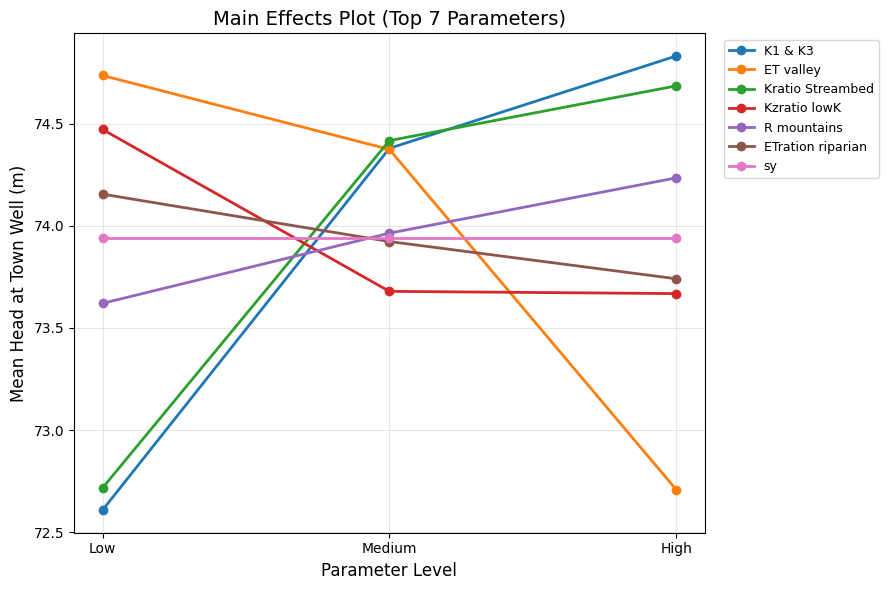

In [327]:
top_n = len(df_param_effects)  # set to total number of parameters for full plot, or a smaller number for top-N
top_params = df_param_effects["parameter_name"].head(top_n).tolist()

main_fx_top = (
    df_param_levels[df_param_levels["parameter_name"].isin(top_params)]
    .pivot(index="parameter_name", columns="choice_label", values="mean_head_m")
    .reindex(top_params)
    [["Low", "Medium", "High"]]
)

plt.figure(figsize=(9, 6))

x_labels = ["Low", "Medium", "High"]
x = [0, 1, 2]

for pname, row in main_fx_top.iterrows():
    y = row.values.astype(float)
    plt.plot(x, y, marker="o", linewidth=2, label=pname)

plt.xticks(x, x_labels)
plt.xlabel("Parameter Level", fontsize=12)
plt.ylabel("Mean Head at Town Well (m)", fontsize=12)
plt.title(f"Main Effects Plot (Top {top_n} Parameters)", fontsize=14)
plt.grid(alpha=0.3)
# plt.legend(loc="best")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Effect-size bar chart (strongest vs weakest parameters)

This makes it very easy to see which parameters matter most/least.

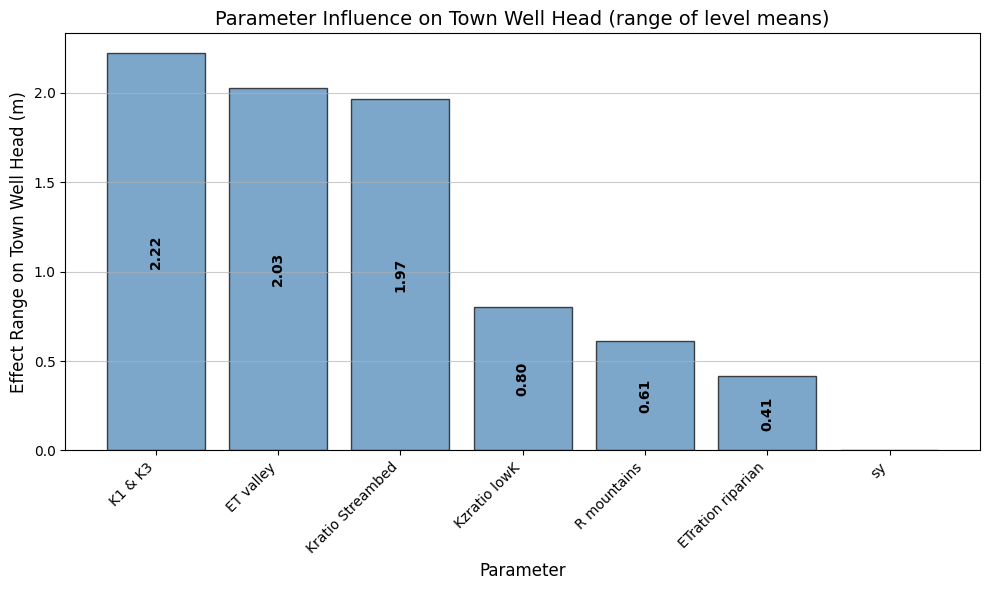

In [328]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df_param_effects["parameter_name"], df_param_effects["effect_range_m"], color='steelblue', edgecolor='black', alpha=0.7)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,              # X position (center of bar)
        height / 2,                                     # Y position (middle of bar)
        f'{""}' if not height else f'{height:.2f}',     # Text to display
        ha='center',                                    # Horizontal alignment
        va='center',                                    # Vertical alignment
        rotation=90,                                    # Rotate text vertically
        fontweight='bold'                               # Bold text
    )

plt.xticks(rotation=45, ha="right")
plt.xlabel("Parameter", fontsize=12)
plt.ylabel("Effect Range on Town Well Head (m)", fontsize=12)
plt.title("Parameter Influence on Town Well Head (range of level means)", fontsize=14)
plt.grid(axis="y", alpha=0.65)
plt.tight_layout()
plt.show()

## Low/Med/High parameter values in a reference table

This is nice to display under the plots so you can interpret the levels.

In [329]:
df_param_effects[[
    "parameter_name",
    "low_value", "med_value", "high_value",
    "mean_head_low", "mean_head_med", "mean_head_high",
    "effect_range_m", "high_minus_low_m"
]].style.format({
    "low_value": "{:.6g}",
    "med_value": "{:.6g}",
    "high_value": "{:.6g}",
    "mean_head_low": "{:.2f}",
    "mean_head_med": "{:.2f}",
    "mean_head_high": "{:.2f}",
    "effect_range_m": "{:.2f}",
    "high_minus_low_m": "{:.2f}",
})

,parameter_name,low_value,med_value,high_value,mean_head_low,mean_head_med,mean_head_high,effect_range_m,high_minus_low_m
0,K1 & K3,5,25,100,72.61,74.38,74.83,2.22,2.22
1,ET valley,1e-06,1e-05,0.0001,74.74,74.37,72.71,2.03,-2.03
2,Kratio Streambed,0.01,0.1,1,72.72,74.42,74.68,1.97,1.97
3,Kzratio lowK,1e-06,0.01,1,74.47,73.68,73.67,0.80,-0.80
4,R mountains,1e-05,3e-05,5e-05,73.62,73.96,74.23,0.61,0.61
5,ETration riparian,1,2,3,74.16,73.92,73.74,0.41,-0.41
6,sy,0.05,0.1,0.3,73.94,73.94,73.94,0.00,0.00


## 3) A simple top-2 parameter interaction check is exactly what you want after the main-effects ranking.

#### The idea is:

* pick the 2 most influential parameters (from df_param_effects)

* build a 3×3 table of mean town-well head for all Low/Med/High combinations

* compare that to what you’d expect from main effects only

* plot it (interaction plot + residual heatmap)

#### Pick the top 2 parameters and build the 3×3 interaction tables

In [ ]:
# Top-2 interaction check (automatic: uses the two strongest parameters from df_param_effects)

# Pick top 2 from your main-effects ranking
top2 = df_param_effects[["parameter_name", "factor_col"]].head(7).copy()

p1_name = top2.iloc[0]["parameter_name"]  # you can select any parameter from the list, but top 2 is a common choice for interaction checks
p1_col  = top2.iloc[0]["factor_col"]

p2_name = top2.iloc[1]["parameter_name"]
p2_col  = top2.iloc[1]["factor_col"]

print(f"Top 1: {p1_name} ({p1_col})")
print(f"Top 2: {p2_name} ({p2_col})")

# Build observed mean head table (3x3)
# rows = p1 levels (1/2/3), cols = p2 levels (1/2/3)
obs_mean_3x3 = (
    df_effect.groupby([p1_col, p2_col], observed=True)["head_town_m"]
    .mean()
    .unstack(p2_col)
    .reindex(index=[1, 2, 3], columns=[1, 2, 3])
)

# Counts table (helps confirm balanced coverage)
obs_count_3x3 = (
    df_effect.groupby([p1_col, p2_col], observed=True)["head_town_m"]
    .count()
    .unstack(p2_col)
    .reindex(index=[1, 2, 3], columns=[1, 2, 3])
    .fillna(0)
    .astype(np.int32)
)

obs_mean_3x3

Top 1: K1 & K3 (f1)
Top 2: ET valley (f5)


f5,1,2,3
f1,,,
1,74.287521,73.412056,70.126915
2,74.934647,74.765778,73.437439
3,74.985641,74.944756,74.563072


## Compute additive expectation and interaction residuals

This is the key interaction check.

In [331]:
# Compute additive expectation (what we'd expect if there were NO interaction)

overall_mean = float(df_effect["head_town_m"].mean())

main_p1 = (
    df_effect.groupby(p1_col, observed=True)["head_town_m"]
    .mean()
    .reindex([1, 2, 3])
)

main_p2 = (
    df_effect.groupby(p2_col, observed=True)["head_town_m"]
    .mean()
    .reindex([1, 2, 3])
)

# Expected under additive model: E[a,b] = mean(p1=a) + mean(p2=b) - overall_mean
exp_add_3x3 = pd.DataFrame(index=[1, 2, 3], columns=[1, 2, 3], dtype=np.float32)
for a in [1, 2, 3]:
    for b in [1, 2, 3]:
        exp_add_3x3.loc[a, b] = np.float32(main_p1.loc[a] + main_p2.loc[b] - overall_mean)

# Interaction residual = observed - additive expectation
int_resid_3x3 = (obs_mean_3x3 - exp_add_3x3).astype(np.float32)

# Simple interaction strength metrics
interaction_absmax_m = np.float32(np.nanmax(np.abs(int_resid_3x3.values)))
interaction_range_m = np.float32(np.nanmax(int_resid_3x3.values) - np.nanmin(int_resid_3x3.values))
interaction_rms_m = np.float32(np.sqrt(np.nanmean(int_resid_3x3.values**2)))

df_interaction_summary = pd.DataFrame({
    "Parameter 1": [p1_name],
    "Factor 1": [p1_col],
    "Parameter 2": [p2_name],
    "Factor 2": [p2_col],
    "Interaction abs max (m)": [interaction_absmax_m],
    "Interaction range (m)": [interaction_range_m],
    "Interaction RMS (m)": [interaction_rms_m],
})

df_interaction_summary

,Parameter 1,Factor 1,Parameter 2,Factor 2,Interaction abs max (m),Interaction range (m),Interaction RMS (m)
0,K1 & K3,f1,ET valley,f5,1.251289,2.213821,0.672097


## Add nice Low/Med/High labels (with actual parameter values)

This makes the tables easier to read.

In [332]:
# Pull parameter values from pc (your param_choice_df copy with factor_col)

row_p1 = pc.loc[pc["factor_col"] == p1_col].iloc[0]
row_p2 = pc.loc[pc["factor_col"] == p2_col].iloc[0]

p1_labels = {
    1: f"Low ({row_p1['Low (1)']})",
    2: f"Medium ({row_p1['Medium (2)']})",
    3: f"High ({row_p1['High (3)']})",
}
p2_labels = {
    1: f"Low ({row_p2['Low (1)']})",
    2: f"Medium ({row_p2['Medium (2)']})",
    3: f"High ({row_p2['High (3)']})",
}

obs_mean_labeled = obs_mean_3x3.copy()
obs_mean_labeled.index = [p1_labels[i] for i in obs_mean_labeled.index]
obs_mean_labeled.columns = [p2_labels[i] for i in obs_mean_labeled.columns]

exp_add_labeled = exp_add_3x3.copy()
exp_add_labeled.index = [p1_labels[i] for i in exp_add_labeled.index]
exp_add_labeled.columns = [p2_labels[i] for i in exp_add_labeled.columns]

int_resid_labeled = int_resid_3x3.copy()
int_resid_labeled.index = [p1_labels[i] for i in int_resid_labeled.index]
int_resid_labeled.columns = [p2_labels[i] for i in int_resid_labeled.columns]

# Display rounded
obs_mean_labeled.style.format("{:.2f}")

,Low (1e-06),Medium (1e-05),High (0.0001)
Low (5.0),74.29,73.41,70.13
Medium (25.0),74.93,74.77,73.44
High (100.0),74.99,74.94,74.56


In [333]:
int_resid_labeled.style.format("{:.2f}")

,Low (1e-06),Medium (1e-05),High (0.0001)
Low (5.0),0.88,0.37,-1.25
Medium (25.0),-0.24,-0.05,0.29
High (100.0),-0.64,-0.32,0.96


## Interaction plot (best visual check)

If the 3 lines are parallel-ish, interaction is weak.

If they cross/spread unevenly, interaction is stronger.


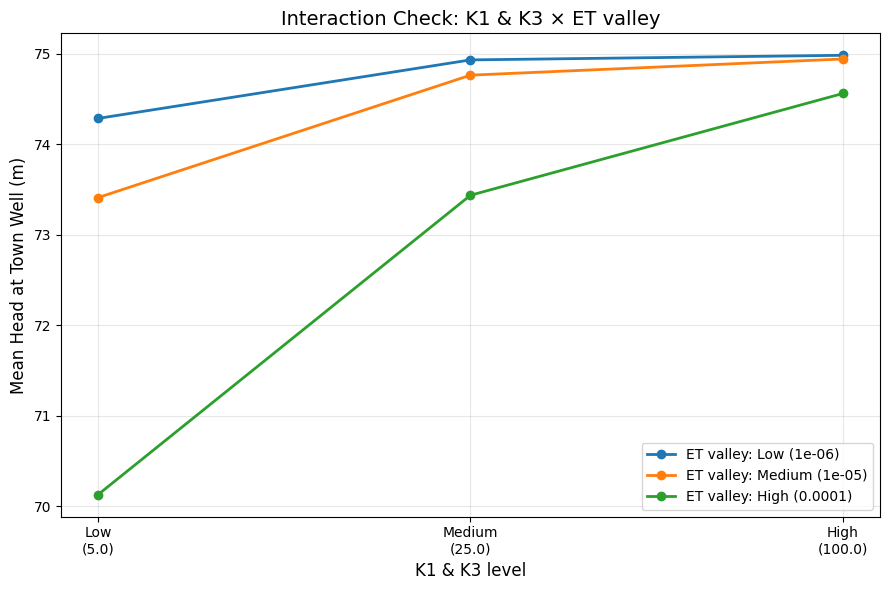

In [334]:
plt.figure(figsize=(9, 6))

x = [0, 1, 2]
x_labels = ["Low", "Medium", "High"]

# Plot lines for p2 levels across p1 levels
for lvl_p2 in [1, 2, 3]:
    y = obs_mean_3x3[lvl_p2].values.astype(float)
    plt.plot(
        x, y,
        marker="o",
        linewidth=2,
        label=f"{p2_name}: {['Low','Medium','High'][lvl_p2-1]} ({ {1:row_p2['Low (1)'],2:row_p2['Medium (2)'],3:row_p2['High (3)']}[lvl_p2] })"
    )

plt.xticks(x, [f"Low\n({row_p1['Low (1)']})", f"Medium\n({row_p1['Medium (2)']})", f"High\n({row_p1['High (3)']})"])
plt.xlabel(f"{p1_name} level", fontsize=12)
plt.ylabel("Mean Head at Town Well (m)", fontsize=12)
plt.title(f"Interaction Check: {p1_name} × {p2_name}", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Residual heatmap (observed − additive expected)

#### This shows interaction directly in meters.

* values near 0 → mostly additive (weak interaction)

* larger positive/negative values → stronger interaction at that combo

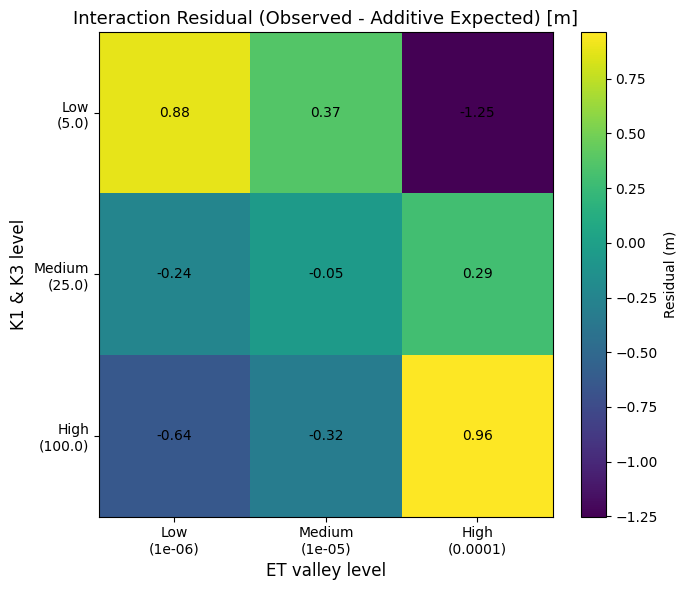

In [335]:
resid = int_resid_3x3.values.astype(float)

plt.figure(figsize=(7, 6))
im = plt.imshow(resid, aspect="auto")

# Axis labels
plt.xticks([0, 1, 2], [f"Low\n({row_p2['Low (1)']})", f"Medium\n({row_p2['Medium (2)']})", f"High\n({row_p2['High (3)']})"])
plt.yticks([0, 1, 2], [f"Low\n({row_p1['Low (1)']})", f"Medium\n({row_p1['Medium (2)']})", f"High\n({row_p1['High (3)']})"])

plt.xlabel(f"{p2_name} level", fontsize=12)
plt.ylabel(f"{p1_name} level", fontsize=12)
plt.title("Interaction Residual (Observed - Additive Expected) [m]", fontsize=13)

# Annotate cells
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{resid[i, j]:.2f}", ha="center", va="center", fontsize=10)

plt.colorbar(im, label="Residual (m)")
plt.tight_layout()
plt.show()